In [ ]:

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

csv_path = Path("../models") / "dt_model_loss_history_checkpoints.csv"
loss_df = pd.read_csv(csv_path, parse_dates=["timestamp"])

pairs = [
    ("train_total_avg", "val_total"),
    ("train_action_avg", "val_action"),
    ("train_state_avg", "val_state"),
    ("train_return_avg", "val_return"),
]

fig, axes = plt.subplots(len(pairs), 1, figsize=(12, 3 * len(pairs)), sharex=True)
for ax, (train_col, val_col) in zip(axes, pairs):
    if train_col not in loss_df and val_col not in loss_df:
        ax.set_visible(False)
        continue
    ax.plot(loss_df["timestamp"], loss_df[train_col], label=train_col)
    if val_col in loss_df:
        ax.plot(loss_df["timestamp"], loss_df[val_col], label=val_col)
    ax.set_ylabel("Loss / Metric")
    ax.set_title(f"{train_col} vs {val_col}")
    ax.legend()
    ax.grid(True)

axes[-1].set_xlabel("Timestamp")
fig.tight_layout()
plt.xticks(rotation=45)
plt.show()


In [1]:
import os

def get_matching_files(directory, pattern):
    """
    Returns a list of file paths in 'directory' whose names contain 'pattern'.
    """
    return [
        os.path.join(directory, fname)
        for fname in os.listdir(directory)
        if pattern in fname
    ]

In [2]:
# fetch log files for evaluation
import re
import polars as pl

# use a looser matcher so files like:
#  - dt_rtg03_test_episode_02_logs.parquet
#  - dt_test_episode_02_rtg03_logs.parquet
# are both returned
matching_files = get_matching_files("../data", "test_episode")

# capture algorithm at start, trailing _logs (allow optional .parquet)
pat = re.compile(r"^(?P<algo>[A-Za-z0-9]+).*?_logs(?:\.parquet)?$", re.IGNORECASE)
# find _rtgNN anywhere in the name
rtg_search_re = re.compile(r"_rtg(?P<rtg>\d+)", re.IGNORECASE)

test_logs: dict[str, pl.DataFrame] = {}
skipped = []

for file_path in matching_files:
    fname = os.path.basename(file_path)
    m = pat.match(fname)
    if not m:
        print(f"Skipping unrecognized filename: {fname}")
        skipped.append(fname)
        continue

    algo = m.group("algo")
    rtg_m = rtg_search_re.search(fname)
    rtg = rtg_m.group("rtg") if rtg_m else None
    label = f"{algo}_rtg{rtg}" if rtg else algo

    # try to read parquet; if unreadable or empty, register empty DF so label exists
    try:
        if os.path.getsize(file_path) == 0:
            df = pl.DataFrame()
            print(f"Warning: zero-byte file -> empty DF for {label}: {fname}")
        else:
            df = pl.read_parquet(file_path)
    except Exception as e:
        print(f"Failed to read {fname}: {e} -> registering empty DF for {label}")
        df = pl.DataFrame()

    # ensure episode_id exists for non-empty frames
    if not df.is_empty() and "episode_id" not in df.columns:
        df = df.with_columns(pl.lit(0).alias("episode_id"))

    test_logs[label] = df
    print(f"Registered: {fname} -> label='{label}', rows={len(df)}")

print("Final labels:", list(test_logs.keys()))
print("Skipped files:", skipped)

Registered: sdp_test_episode_01_logs.parquet -> label='sdp', rows=883329
Registered: oracle_test_episode_01_logs.parquet -> label='oracle', rows=109024
Registered: rule_test_episode_01_logs.parquet -> label='rule', rows=862988
Registered: mrdp_test_episode_01_logs.parquet -> label='mrdp', rows=850110
Final labels: ['sdp', 'oracle', 'rule', 'mrdp']
Skipped files: []


In [3]:
# Split into a list of DataFrames, one per episode

all_logs = {
    label: [df.filter(pl.col("episode_id") == eid) for eid in df["episode_id"].unique()]
    for label, df in test_logs.items()
}

In [4]:
from helper import find_problematic_episodes
"""
all_logs: dict[str, list[pl.DataFrame]]
    Mapping from algorithm/label → list of Polars DataFrames (one DataFrame per episode). Each DataFrame is expected to contain columns like reward, rtg, timestep, state_*, action_* and episode_id already split.
reward_thresh: float
    Threshold for maximum absolute reward to flag (default 1e5).
rtg_thresh: float | None
    Threshold for maximum absolute rtg to flag. If None the function will not flag rtg magnitude issues (but rtg values are still used to compute suggested_return_scale).
state_thresh: float
    Threshold for maximum absolute value across state_* columns to flag (default 1e3).
action_thresh: float
    Threshold for maximum absolute value across action_* columns to flag (default 1e3).
max_timestep: int | None
    If set, flags episodes where timestep/time/step maximum exceeds this value.
rtg_percentile_for_scale: int
    Percentile of per-episode median(|rtg|) used to compute suggested_return_scale (default 90).
target_90th_after_scaling: float
    Desired value for that percentile after scaling (default 10.0). The suggested scale = percentile_value / target_90th_after_scaling (bounded ≥ 1.0).

This function returns a tuple: (reports, suggested_return_scale).
reports is a list of dicts; each dict has:
    algorithm: str — algorithm / file label containing the episode.
    episode_index: int — index of the episode within all_logs[algorithm].
    rows: int — number of rows in that episode DataFrame (0 if empty).
    issues: list[str] — concise problem tags / messages. Typical entries:
        "empty_episode" — episode dataframe is empty.
        "{col}: NaN=X,+Inf=Y,-Inf=Z" — column contains NaN/Inf counts.
        "reward_mag>{reward_thresh}" — reward absolute max exceeded threshold.
        "rtg_mag>{rtg_thresh}" — rtg absolute max exceeded threshold (if rtg_thresh provided).
        "state_mag>{state_thresh}" — any state_* column exceeded threshold.
        "action_mag>{action_thresh}" — any action_* column exceeded threshold.
        "{tcol}_>{max_timestep}" — timestep/time/step column exceeded allowed max.

The suggested_return_scale is a float computed from the distribution of episode median |rtg| values.
    
"""
problems, suggested_scale = find_problematic_episodes(
    all_logs,
    reward_thresh=1e5,
    state_thresh=1e3,
    max_timestep=20000
)


Problematic episodes by algorithm:
  oracle: 48 episodes
  rule: 3 episodes
  mrdp: 2 episodes
First 20 problem rows:
algorithm  episode_index  rows                issues
   oracle              1   276 [reward_mag>100000.0]
   oracle              2   324 [reward_mag>100000.0]
   oracle              3   373 [reward_mag>100000.0]
   oracle              4   755 [reward_mag>100000.0]
   oracle              6   563 [reward_mag>100000.0]
   oracle              7   943 [reward_mag>100000.0]
   oracle              9  1236 [reward_mag>100000.0]
   oracle             10   994 [reward_mag>100000.0]
   oracle             12   324 [reward_mag>100000.0]
   oracle             13   129 [reward_mag>100000.0]
   oracle             14   276 [reward_mag>100000.0]
   oracle             15   563 [reward_mag>100000.0]
   oracle             16  1425 [reward_mag>100000.0]
   oracle             17  2013 [reward_mag>100000.0]
   oracle             18  1044 [reward_mag>100000.0]
   oracle             20  1233 [re

In [5]:
problems

[{'algorithm': 'oracle',
  'episode_index': 1,
  'rows': 276,
  'issues': ['reward_mag>100000.0']},
 {'algorithm': 'oracle',
  'episode_index': 2,
  'rows': 324,
  'issues': ['reward_mag>100000.0']},
 {'algorithm': 'oracle',
  'episode_index': 3,
  'rows': 373,
  'issues': ['reward_mag>100000.0']},
 {'algorithm': 'oracle',
  'episode_index': 4,
  'rows': 755,
  'issues': ['reward_mag>100000.0']},
 {'algorithm': 'oracle',
  'episode_index': 6,
  'rows': 563,
  'issues': ['reward_mag>100000.0']},
 {'algorithm': 'oracle',
  'episode_index': 7,
  'rows': 943,
  'issues': ['reward_mag>100000.0']},
 {'algorithm': 'oracle',
  'episode_index': 9,
  'rows': 1236,
  'issues': ['reward_mag>100000.0']},
 {'algorithm': 'oracle',
  'episode_index': 10,
  'rows': 994,
  'issues': ['reward_mag>100000.0']},
 {'algorithm': 'oracle',
  'episode_index': 12,
  'rows': 324,
  'issues': ['reward_mag>100000.0']},
 {'algorithm': 'oracle',
  'episode_index': 13,
  'rows': 129,
  'issues': ['reward_mag>100000.0'

In [6]:
# pick one problematic episode
algo, ep = "rule", 20
df = all_logs[algo][ep]
# examine the last few rows
df.tail(10)['info'][-1]

{'battery_flow_energy': 0.33000001311302185,
 'battery_level': 1.7303430882529938,
 'grid_energy': 1.565999984741211,
 'energy_price': 0.15,
 'grid_cost': 0.23490001261234283,
 'grid_reward': -0.23490001261234283,
 'dynamic_interval': 0,
 'dynamic_updated': False,
 'deg_cost': 0.0,
 'last_dynamic_deg': 0.42933104563287044,
 'last_num_cycles': 4628,
 'new_cycles_in_step': 0,
 'rainflow_cumulative_deg': 0.42933104563287044,
 'energy_conservation_violation': False,
 'step_degradation': 0.0,
 'total_degradation': 0.42933104563287044,
 'capacity_kwh': 3.9946826805699063,
 'current_step': 17517,
 'deg_error': ''}

In [7]:
print(len(df))

17518


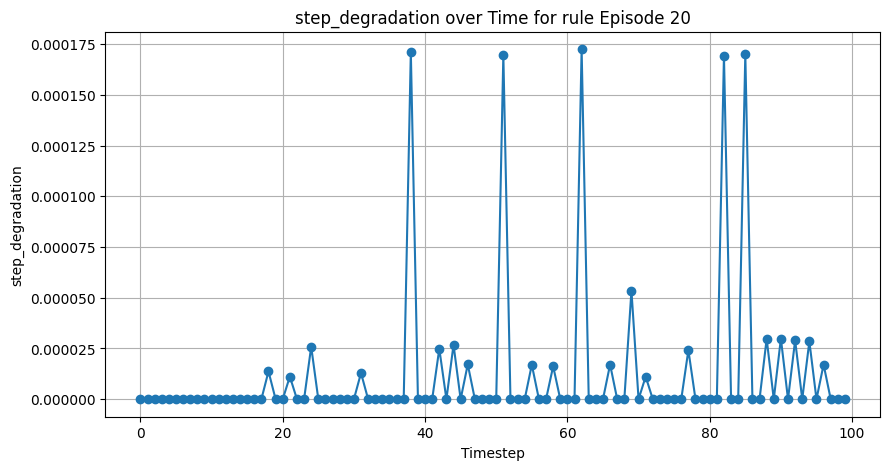

In [16]:
# examine any element from info and plot it
import matplotlib.pyplot as plt
info_list = []
debug_element = "step_degradation"
for info in df['info']:
    if info is None:
        info_list.append(None)
    elif isinstance(info, dict):
        info_list.append(info.get(debug_element))
    else:
        try:
            j = json.loads(info)
            if isinstance(j, dict):
                info_list.append(j.get(debug_element))
            else:
                info_list.append(None)
        except Exception:
            info_list.append(None)

info_list = info_list[:100]
# plot the extracted element over time
plt.figure(figsize=(10, 5))
plt.plot(info_list, marker='o', linestyle='-')
plt.xlabel('Timestep')
plt.ylabel(debug_element)
plt.title(f'{debug_element} over Time for {algo} Episode {ep}')
plt.grid(True)
plt.show()
 

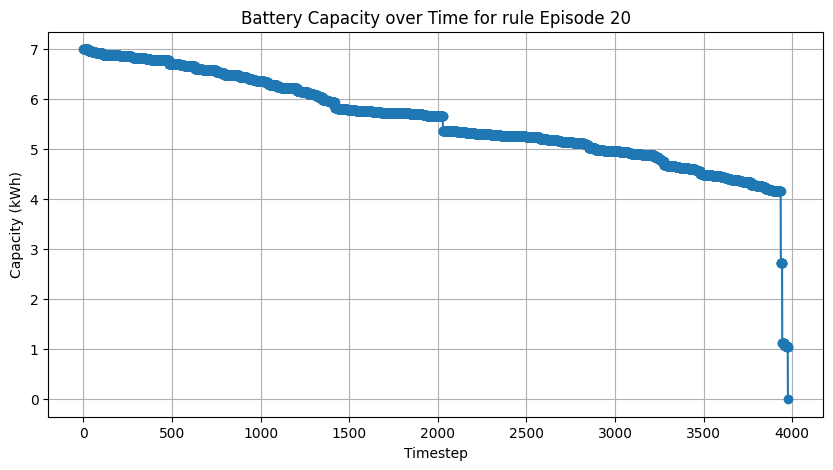

In [47]:
# plot capacity_kwh over time
plt.figure(figsize=(10, 5))
plt.plot(capacity_kwhs, marker='o', linestyle='-')
plt.xlabel('Timestep')
plt.ylabel('Capacity (kWh)')
plt.title(f'Battery Capacity over Time for {algo} Episode {ep}')
plt.grid(True)
plt.show()

In [38]:
# examine battery_level from info
battery_levels = []
num = 4000
for info in df.tail(num)['info']:
    if info is None:
        battery_levels.append(None)
    elif isinstance(info, dict):
        battery_levels.append(info.get('battery_level'))
    else:
        try:
            j = json.loads(info)
            if isinstance(j, dict):
                battery_levels.append(j.get('battery_level'))
            else:
                battery_levels.append(None)
        except Exception:
            try:
                j = ast.literal_eval(info)
                if isinstance(j, dict):
                    battery_levels.append(j.get('battery_level'))
                else:
                    battery_levels.append(None)
            except Exception:
                battery_levels.append(None) 

In [39]:
import numpy as np
from batterydeg import rainflow_counting

battery_capacity = 7.0  # or env.battery_capacity
soc = (np.array(battery_levels, dtype=float) / battery_capacity) * 100.0

cycles = rainflow_counting(soc, step_duration=0.5)
print("Turning-point cycles detected:", len(cycles))
if len(cycles) > 0:
    print("First 5 cycles:", cycles[:5])

Turning-point cycles detected: 275
First 5 cycles: [(np.float64(51.00244890366282), np.float64(90.31106723206385), np.float64(25.80316206630396), 0.0), (np.float64(51.12866321578622), np.float64(92.15864179922002), np.float64(15.359773633203337), 0.0), (np.float64(51.241085971040384), np.float64(92.43358543940953), 0.0, np.float64(23.10839635985238)), (np.float64(49.56998888935362), np.float64(80.9442034789494), 0.0, np.float64(23.12691527969983)), (np.float64(45.97181124346597), np.float64(91.94362248693194), 0.0, np.float64(22.985905621732986))]


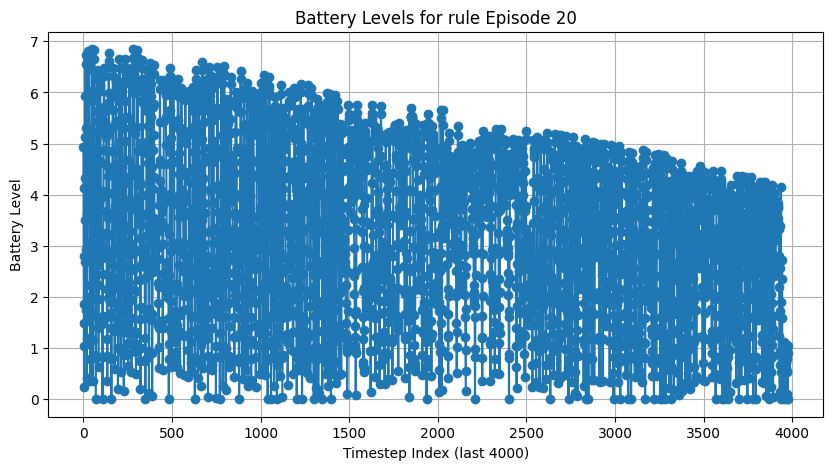

In [40]:
# plot battery levels
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(battery_levels, marker='o')
plt.title(f'Battery Levels for {algo} Episode {ep}')
plt.xlabel(f'Timestep Index (last {num})')
plt.ylabel('Battery Level')
plt.grid(True)
plt.show()

In [ ]:
from pathlib import Path
from helper import evaluate_experiments

base_save_dir = "../eval_output"

# evaluate experiments outcomes
metrics = evaluate_experiments(all_logs, target_return=0.0, save_dir=str(base_save_dir))

# log metrics as csv
metrics_csv_path = Path(base_save_dir) / "evaluation_metrics.csv"
metrics.write_csv(str(metrics_csv_path))
print(f"Saved evaluation metrics to: {metrics_csv_path}")



In [ ]:
# just getting the recommended RTG values
from helper import evaluate_experiments
metrics = evaluate_experiments(all_logs, target_return=0.0, save_dir=None)

# 1. If you want the best RTG across ALL experiments/datasets provided:
best_overall_rtg = metrics["recommended_rtg"].max()
print(f"Best RTG to use: {best_overall_rtg}")

# 2. If you only want the RTG for a specific dataset (e.g. 'SAC_training_data'):
# Filter for that specific experiment name
specific_rtg = metrics.filter(pl.col("experiment") == "rule")["recommended_rtg"][0]
print(f"RTG for SAC data: {specific_rtg}")

In [ ]:
for algo, logs in all_logs.items():
    print(f"{algo}: {len(logs)} episodes")

In [ ]:
from typing import Any
from helper import AlgorithmActionComparator, ActionComparisonConfig
def compare_action_pairwise_to_reference(
    logs_dict: dict[str, list[pl.DataFrame]],
    reference: str,
    base_save_dir: str | Path | None = None,
    **kwargs: Any,
 ) -> dict[str, Any]:
    """
    Run pairwise comparisons of each algorithm vs a reference algorithm.
    
    kwargs are forwarded to ActionComparisonConfig (e.g., bins, time_periods, etc.).
    Returns a dict: algo_name -> ActionComparisonResult or metrics dict.
    """
    comparator = AlgorithmActionComparator(action_logs=logs_dict)
    results: dict[str, Any] = {}
    for algo in logs_dict:
        if algo == reference:
            continue
        sub_logs = {reference: logs_dict[reference], algo: logs_dict[algo]}
        # If a base_save_dir is provided, create a per-pair subdirectory so output files don't overwrite each other
        if base_save_dir:
            out_dir = Path(base_save_dir) / f"{reference}_vs_{algo}"
            out_dir.mkdir(parents=True, exist_ok=True)
            kwargs_copy = dict(kwargs)
            # ensure we set save_dir to output dir
            kwargs_copy["save_dir"] = str(out_dir)
        else:
            kwargs_copy = kwargs
        cfg = ActionComparisonConfig(reference=reference, **kwargs_copy)
        result = comparator.compare(logs_dict=sub_logs, config=cfg)
        results[algo] = result
    return results


In [ ]:
steps_per_hour = int(1 / 0.5)  # number of steps per hour given a 30-min step duration (2)

def time_to_step(hour: int, minute: int = 0, second: int = 0, steps_per_hour_: int | None = None) -> int:
    """
    Convert a time-of-day (hour, minute, second) into a 0-indexed step mark for that day,
    using steps_per_hour (defaults to `steps_per_hour` defined above).
    Returns the floor of the step (i.e., which step interval that timestamp falls into).
    """
    sp = steps_per_hour_ or steps_per_hour
    total_seconds = hour * 3600 + minute * 60 + second
    seconds_per_step = 3600 / sp
    return int(total_seconds // seconds_per_step)

# time periods to compare in steps
# first 2 days, 2 days after 4th week, 2 days after 4th month, 2 days at 11th month (assuming 30-min per step, 48 steps/day)
first_step = 0
fourth_week = 4 * 7 * 48  # 4th week
fourth_month = 4 * 30 * 48  # 4th month
eleventh_month = 11 * 30 * 48  # 11th month
two_day_steps = 2 * 48

# morning period markers
five_am_mark = time_to_step(5, 0)   # 05:00
ten_am_mark = time_to_step(10, 0)   # 10:00

# mid-day marker
three_pm_mark = time_to_step(15, 0)  # 15:00

# evening marker
nine_pm_mark = time_to_step(21, 0)   # 21:00

# pick 52nd episode if exists for all algorithms
episode_52 = {}
for algo, logs in all_logs.items():
    if len(logs) > 52:
        episode_52[algo] = logs[52]

# Wrap single-episode DataFrames into lists expected by the comparator
episode_single = {k: [v] for k, v in episode_52.items()}

# check if we have data for episode 52
if not episode_52:
    print("No data available for episode 52 across the algorithms.")

In [ ]:
# overall comparison for action stat
base_save_dir = "../eval_output"
pairwise_results = compare_action_pairwise_to_reference(
    all_logs,
    reference="rule",
    base_save_dir=base_save_dir,
    time_periods=None,
    bins='auto',
    max_episodes=20 # only uses 20 episodes to compile the stat
 )

In [ ]:
"""
# Example: create named time windows (start_step, end_step) you can pass to the comparator
time_periods = {
    "first_2_days": (first_step, first_step + two_day_steps),
    "4th_week_2_days": (fourth_week, fourth_week + two_day_steps),
    "4th_month_2_days": (fourth_month, fourth_month + two_day_steps),
    "11th_month_2_days": (eleventh_month, eleventh_month + two_day_steps),
    "morning": (first_step + five_am_mark, first_step + ten_am_mark),
    "afternoon": (first_step + three_pm_mark, first_step + three_pm_mark + steps_per_hour),  # 1-hour window
    "evening": (first_step + nine_pm_mark, first_step + nine_pm_mark + steps_per_hour),     # 1-hour window
}
"""

time_periods = [
    (fourth_week, fourth_week + two_day_steps/2),
]

In [ ]:
from helper import AlgorithmActionComparator, TemporalAnalysisConfig
import matplotlib.pyplot as plt

# Use the same time_periods defined earlier and the episode_8964 mapping (algo -> DataFrame)
# episode_8964 maps algorithm -> single episode DataFrame; analyze_temporal expects dict[str, pl.DataFrame]
base_save_dir = "../eval_output"
comparator = AlgorithmActionComparator()
# Build a unique filename for the episode and involved algos

temporal_out_path = base_save_dir + "/temporal"
cfg = TemporalAnalysisConfig(time_periods=time_periods, annotate_states=True, step_duration=0.5, reference="rule", action_tolerance=0.01, save_path=str(temporal_out_path))

result = comparator.analyze_temporal(logs_dict=episode_52, config=cfg)
fig = result.figure
stats = result.stats

# Display stats and figure
print(stats)
# In notebooks, use display of Matplotlib figure
plt.show(fig)


In [ ]:
# Example: Evaluate rewards under different conditions for one algorithm
from helper import evaluate_by_conditions

# Define your conditions (functions that take obs and return True/False)
conditions = {
    "high_solar": lambda obs: obs[5] > 2.0,
    "peak_price": lambda obs: obs[7] > 0.2,
    "low_battery": lambda obs: obs[-2] < 0.3
}

# logs is a list of Polars DataFrames for one algorithm
results = evaluate_by_conditions(logs, conditions)
print(results)